# MLQGPS

Same training as `DLQPM.ipynb`: lnZ, lattice losses, Plumari mass ratios, AdamW.
Architecture: simple DNN. Weights: `mlqgps_model/MLQGPS_{Mud,Ms,Mg}.pt`.

While training, this notebook prints the epoch, train loss, validation loss, and the percent errors, and draws the loss graph. Masses and Seebeck are not computed here. Open `LIVE MONITOR.ipynb` in a second kernel; it reloads the saved weights and redraws those plots every 100 epochs. Press the square Stop button on the training cell to halt. The best weights already written stay in `mlqgps_model`.


In [1]:
# Block 1
# Imports

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import torch.optim as optim
import time
import matplotlib.pyplot as plt
from torch.optim import lr_scheduler
from sklearn.model_selection import train_test_split
from IPython.display import display

_cwd = os.getcwd()
if os.path.isfile(os.path.join(_cwd, "Thermo_data_central.csv")):
    ROOT = _cwd
elif os.path.isfile(os.path.join(os.path.dirname(_cwd), "Thermo_data_central.csv")):
    ROOT = os.path.dirname(_cwd)
else:
    ROOT = r"d:\ML CURSOR\MLQGP"
print("ROOT", ROOT)


ROOT d:\ML CURSOR\MLQGP


In [2]:
# Block 2
# Seeding the RNG

#seed_ini = np.random.randint(0, 2 ** 31 -1)
seed_ini=1639679222
print(seed_ini)
def setup_seed(seed):   
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
setup_seed(seed_ini)

1639679222


In [3]:
# Block 3
# Simple DNN: Input(2) -> Linear(64, swish) x4 -> Linear(1), 2*sigmoid

class Net_Mass(nn.Module):
    def __init__(self, input, output):
        super(Net_Mass, self).__init__()
        self.fc1 = nn.Linear(input, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 64)
        self.fc5 = nn.Linear(64, output)

    def forward(self, x):
        o = self.act(self.fc1(x))
        o = self.act(self.fc2(o))
        o = self.act(self.fc3(o))
        o = self.act(self.fc4(o))
        opt = self.output_layer_act(self.fc5(o))
        return opt

    def act(self, x):
        return x * torch.sigmoid(x)

    def output_layer_act(self, x):
        return torch.sigmoid(x) * 2


In [4]:
# Block 7
# partition function of quark and gluon
def lnZ_q(T,  m,  mu, eta):
    deg = 50
    xk, wk = np.polynomial.laguerre.laggauss(deg=deg)
    pnodes = torch.from_numpy(xk).to(device)
    wnodes = torch.from_numpy(wk).to(device)
    rnodes =  torch.exp(-pnodes)
    psqure = pnodes**2
    E = (psqure + m ** 2) ** 0.5
    E_mu = E - mu
    efactor = torch.exp(-E_mu/T)
    f = efactor * eta
    f = f + 1
    f = torch.log(f)
    f = psqure * eta * f
    f = wnodes * f
    f = f/rnodes
    f = torch.sum(f,1)
    return f.reshape(-1,1)

def lnZ_g(T, m, eta):
    deg = 50
    xk, wk = np.polynomial.laguerre.laggauss(deg=deg)
    pnodes = torch.from_numpy(xk).to(device)
    wnodes = torch.from_numpy(wk).to(device)
    
    rnodes =  torch.exp(-pnodes)
    psqure = pnodes**2
    E = (psqure + m ** 2) ** 0.5
    efactor = torch.exp(-E/T)
    f = efactor * eta
    f = f + 1
    f = torch.log(f)
    f = psqure*eta * f
    f = wnodes * f
    f = f/rnodes
    f = torch.sum(f,1)
    return  f.reshape(-1,1)


In [5]:
# Block 5
# training the Network

def Mass_Tmu_train(learning_rate, epochs, path, device):
    """
    return: loss, and save model
    """

    Net1 = Net_Mass(2,1).to(device)
    Net2 = Net_Mass(2,1).to(device)
    Net3 = Net_Mass(2,1).to(device)
    
    opt1 = optim.AdamW(Net1.parameters(),lr = learning_rate,betas=(0.9,0.999))
    opt2 = optim.AdamW(Net2.parameters(),lr = learning_rate,betas=(0.9,0.999))
    opt3 = optim.AdamW(Net3.parameters(),lr = learning_rate,betas=(0.9,0.999))
    
    lr_step_size = 2000

    schedular1 = lr_scheduler.StepLR(opt1, step_size=lr_step_size, gamma=0.92)    
    schedular2 = lr_scheduler.StepLR(opt2, step_size=lr_step_size, gamma=0.92)    
    schedular3 = lr_scheduler.StepLR(opt3, step_size=lr_step_size, gamma=0.92)    
    
    def init_normal(m):
        if type(m) == nn.Linear:
            nn.init.kaiming_uniform_(m.weight)
            
    Net1.apply(init_normal)
    Net1.train()
    Net2.apply(init_normal)
    Net2.train()    
    Net3.apply(init_normal)
    Net3.train()    
    

    
    # loss function
    def loss_a(T, muB, Tv, mubv):

        T.requires_grad = True
        muB.requires_grad = True
        Tv.requires_grad = True
        mubv.requires_grad = True        
        
        mu_ud = 1/3 * muB
        mu_s = 1/3 * muB
        mu_udv = 1/3 * mubv
        mu_sv = 1/3 * mubv        
        
        inp1 = torch.cat((T, muB),1)
        inp2 = torch.cat((T, muB),1)
        inp3 = torch.cat((T, muB),1)
        inp4 = torch.cat((Tv, mubv),1)
        inp5 = torch.cat((Tv, mubv),1)
        inp6 = torch.cat((Tv, mubv),1)        
        
        # Obtain Mass
        Mud = Net1(inp1)
        Ms = Net2(inp2)
        Mgluon = Net3(inp3)
        #validation mass 
        MudV = Net1(inp4)
        MsV = Net2(inp5)
        MgluonV = Net3(inp6)  
    
        
        coef =  1 / (2 * torch.pi**2)   
        ud_dof = 2 * 2 * 3  #u,d * q, qbar * spin_dof * color_dof
        s_dof = 2 * 3
        gluon_dof = 8 * 2       # color dof * polarization dof       
        
        # Training 
        lnZ_ud =  ud_dof * coef * lnZ_q(T, Mud, mu_ud, 1) + ud_dof * coef * lnZ_q(T, Mud, -mu_ud, 1)        
        lnZ_s = s_dof * coef * lnZ_q(T, Ms, mu_s, 1) + s_dof * coef * lnZ_q(T, Ms, -mu_s, 1)
        lnZ_gluon = gluon_dof * coef * lnZ_g(T, Mgluon, -1)

        lnZ_tot = lnZ_ud + lnZ_s + lnZ_gluon
   

        dlnZdT =  torch.autograd.grad(lnZ_tot, T, grad_outputs=torch.ones_like(T).to(device),create_graph=True)[0]
        dlnZdmu = torch.autograd.grad(lnZ_tot, muB, grad_outputs=torch.ones_like(muB).to(device),create_graph=True)[0]

        # validation
        lnZ_udv =  ud_dof * coef * lnZ_q(Tv, MudV, mu_udv, 1) + ud_dof * coef * lnZ_q(Tv, MudV, -mu_udv, 1)        
        lnZ_sv = s_dof * coef * lnZ_q(Tv, MsV, mu_sv, 1) + s_dof * coef * lnZ_q(Tv, MsV, -mu_sv, 1)
        lnZ_gluonv = gluon_dof * coef * lnZ_g(Tv, MgluonV, -1)

        lnZ_totv = lnZ_udv + lnZ_sv + lnZ_gluonv

    
        dlnZdTv =  torch.autograd.grad(lnZ_totv, Tv, grad_outputs=torch.ones_like(Tv).to(device),create_graph=True)[0]
        dlnZdmuv = torch.autograd.grad(lnZ_totv, mubv, grad_outputs=torch.ones_like(mubv).to(device),create_graph=True)[0]


        nd = T * dlnZdmu # particle number density
        pr = T * lnZ_tot  # pressure
        s_pred = T * dlnZdT  +  lnZ_tot # entropy
        ed = T * s_pred - pr + muB * nd  #  energy density  
        Delta = (ed - 3 * pr)

        ndv = Tv * dlnZdmuv # particle number density
        prv = Tv * lnZ_totv  # pressure
        s_predv = Tv * dlnZdTv  +  lnZ_totv # entropy
        edv = Tv * s_predv - prv + mubv * ndv  #  energy density  
        Deltav = (edv - 3 * prv)

        pi = torch.pi
        Mu2 = (muB/(pi))**2
        Mu2v = (mubv/(pi))**2

        lamb = 2.6
        Tsr = 0.57
        # >>> no_grad block for reference masses <<<
        with torch.no_grad():

            g2 = (48/27) * (pi**2) / torch.log((lamb*(T/0.155 - Tsr))**2)
            Mgsq = (1/6)*g2*((9/2)*(T**2) + Mu2/2)
            Mudsq = (1/3)*g2*(T**2 + Mu2/9)
            Mssq = .095 **2 + Mudsq
            MudR = torch.sqrt(Mgsq/Mudsq)
            MsR = torch.sqrt(Mgsq/Mssq)

        # only nets are differentiable now
        mass_loss_1 = torch.where(T > (0.8*0.150),
                                  torch.abs(Mgluon/Mud - MudR),
                                  torch.zeros_like(T).to(device))

        mass_loss_2 = torch.where(T > (0.8*0.150),
                                  torch.abs(Mgluon/Ms - MsR),
                                  torch.zeros_like(T).to(device))
        beta1 = 0.01
        beta2 = 0.01
        L_mass = mass_loss_1*beta1 + mass_loss_2*beta2

        # >>> no_grad block for reference masses <<<
        with torch.no_grad():

            g2v = (48/27) * (pi**2) / torch.log((lamb*(Tv/0.155 - Tsr))**2)
            Mgsqv = (1/6)*g2v*((9/2)*(Tv**2) + Mu2v/2)
            Mudsqv = (1/3)*g2v*(Tv**2 + Mu2v/9)
            Mssqv = .095 **2 + Mudsqv
            MudRv = torch.sqrt(Mgsqv/Mudsqv)
            MsRv = torch.sqrt(Mgsqv/Mssqv)

        # only nets are differentiable now
        mass_loss_1v = torch.where(Tv > (0.8*0.150),
                                  torch.abs(MgluonV/MudV - MudRv),
                                  torch.zeros_like(Tv).to(device))

        mass_loss_2v = torch.where(Tv > (0.8*0.150),
                                  torch.abs(MgluonV/MsV - MsRv),
                                  torch.zeros_like(Tv).to(device))
        beta1 = 0.01
        beta2 = 0.01
        L_massv = mass_loss_1v*beta1 + mass_loss_2v*beta2

        sam = len(s_true)
        loss_mae = nn.L1Loss()
        loss1 = loss_mae(s_pred[0:sam], s_true).to(device)
        loss2 = loss_mae(Delta[0:sam]/T[0:sam], D_true/T[0:sam]).to(device)
        loss3 = loss_mae(L_mass , torch.zeros_like(L_mass)).to(device) 
        loss4 = loss_mae(nd[0:sam], nB_true).to(device)
        loss_tot = loss1+ loss2 + loss3 + loss4

        # validation loss
        sam_valid = len(s_valid)
        loss_maev = nn.L1Loss()
        loss1v = loss_maev(s_predv[0:sam_valid], s_valid).to(device)
        loss2v = loss_maev(Deltav[0:sam_valid]/Tv[0:sam_valid], d_valid/Tv[0:sam_valid]).to(device)
        loss3v = loss_maev(L_massv , torch.zeros_like(L_massv)).to(device)
        loss4v = loss_mae(ndv[0:sam], nB_valid).to(device)

        loss_totv = loss1v+ loss2v + loss3v + loss4v

        def _pct(pred, true):
            # Mean |pred-true|/|true| in percent. Points much smaller than the
            # peak of that variable are left out so a near-zero n_B does not blow up.
            p = pred.detach().reshape(-1)
            t = true.detach().reshape(-1)
            scale = torch.max(torch.abs(t))
            if float(scale) < 1e-12:
                return 0.0
            use = torch.abs(t) > (0.01 * scale)
            if not bool(torch.any(use)):
                use = torch.ones_like(t, dtype=torch.bool)
            return float((100.0 * torch.mean(torch.abs(p[use] - t[use]) / torch.abs(t[use]))).item())

        pct_parts = (
            _pct(pr, P_true),
            _pct(ed, E_true),
            _pct(s_pred, s_true),
            _pct(nd, nB_true),
            _pct(Delta, D_true),
        )
        total_pct = float(sum(pct_parts))

        return loss_tot, loss1, loss2, loss3, ed, pr, s_pred, Delta, Mud, Ms, Mgluon, loss_totv, total_pct, pct_parts


    tic = time.time()
    Loss_list = []
    Loss_list_validation = []
    Loss_mean = 1e5

    Thermo = pd.read_csv(os.path.join(ROOT, "Thermo_data_central.csv"))

    df1, df2 = train_test_split(Thermo,
        test_size=0.2,
        random_state=42, 
        shuffle=True    
    )

    s_true = df1["s/T^3"] * df1["T"] ** 3
    E_true = df1["E/T^4"] * df1["T"] ** 4
    P_true = df1["P/T^4"] * df1["T"] ** 4
    D_true = E_true - 3 * P_true
    nB_true = df1["nB/T^3"] * df1["T"] ** 3

    s_valid = df2["s/T^3"] * df2["T"] ** 3
    e_valid = df2["E/T^4"] * df2["T"] ** 4
    p_valid = df2["P/T^4"] * df2["T"] ** 4
    d_valid = e_valid - 3 * p_valid
    nB_valid = df2["nB/T^3"] * df2["T"] ** 3

    Tem = df1["T"].values
    muB = df1["MuB"].values
    T_valid = df2["T"].values
    mub_valid = df2["MuB"].values

    sam = len(s_true)
    sam_valid = len(s_valid)

    Tem = torch.FloatTensor(Tem).reshape(-1,1).to(device)  
    muB = torch.FloatTensor(muB).reshape(-1,1).to(device)  
    D_true = torch.FloatTensor(D_true).reshape(-1,1).to(device)     
    s_true = torch.FloatTensor(s_true).reshape(-1,1).to(device)     
    P_true = torch.FloatTensor(P_true).reshape(-1,1).to(device)     
    E_true = torch.FloatTensor(E_true).reshape(-1,1).to(device)     
    nB_true = torch.FloatTensor(nB_true).reshape(-1,1).to(device)  

    T_valid = torch.FloatTensor(T_valid).reshape(-1,1).to(device)  
    mub_valid = torch.FloatTensor(mub_valid).reshape(-1,1).to(device)  
    d_valid = torch.FloatTensor(d_valid.values).reshape(-1,1).to(device)     
    s_valid = torch.FloatTensor(s_valid.values).reshape(-1,1).to(device)     
    p_valid = torch.FloatTensor(p_valid.values).reshape(-1,1).to(device)     
    e_valid = torch.FloatTensor(e_valid.values).reshape(-1,1).to(device)   
    nB_valid = torch.FloatTensor(nB_valid.values).reshape(-1,1).to(device)  

    # Live graph. Stop this cell with the square Stop button when the curves look good enough.
    print("Loss monitor stays in this cell.")
    print("Open LIVE MONITOR.ipynb in another kernel. It redraws masses and Seebeck every 100 epochs.")
    print("To stop on the spot, press the square Stop button on this cell.")
    print("The best weights already saved are kept.")
    plt.ioff()
    pct_list = []
    fig_live, (ax_loss, ax_pct) = plt.subplots(1, 2, figsize=(11, 3.6))
    line_tr, = ax_loss.plot([], [], label="Train loss")
    line_va, = ax_loss.plot([], [], label="Validation loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)
    line_pct, = ax_pct.plot([], [], color="C3", label="Total % loss")
    ax_pct.set_xlabel("Epoch")
    ax_pct.set_ylabel("Total % loss")
    ax_pct.legend()
    ax_pct.grid(True, alpha=0.3)
    fig_live.tight_layout()
    live_handle = display(fig_live, display_id="mlqgps_live_loss")

    # Each step of the training process:
    epoch = -1
    stopped_early = False
    try:
        for epoch in range(epochs):
            Loss = []
            Loss_validation = []
            Net1.zero_grad()
            Net2.zero_grad()
            Net3.zero_grad()
            loss, loss1, loss2, loss3, energy, pre, entropy, Trace, Mud, Ms, Mgluon, loss_valid, total_pct, pct_parts = loss_a(Tem, muB, T_valid, mub_valid)

            # Back propagation and optimizer
            loss.backward()
            opt1.step()
            opt2.step()
            opt3.step()
            schedular1.step()
            schedular2.step()
            schedular3.step()
            lr = schedular1.get_last_lr()[0]

            # print the loss value
            Loss.append(loss.item())
            Loss_validation.append(loss_valid.item())
            print("Epoch : %d" % (epoch + 1))
            print("Train Loss : %.6e" % loss.item())
            print("Validation Loss : %.6e" % loss_valid.item())
            print("Total %% loss : %.4f          Avg %% loss : %.4f" % (total_pct, total_pct / 5.0))
            print("    P %.3f%%  +  E %.3f%%  +  S %.3f%%  +  nB %.3f%%  +  trace %.3f%%" % pct_parts)
            Loss = np.array(Loss)
            Loss_validation = np.array(Loss_validation)
            # check the loss and save the model
            if np.mean(Loss) < Loss_mean:
                checkpoint1 = {
                        'epoch': epoch + 1,
                        'state_dict': Net1.state_dict(),
                        'optimizer': opt1.state_dict(),
                        'loss': loss.item()
                        }
                checkpoint2 = {
                        'epoch': epoch + 1,
                        'state_dict': Net2.state_dict(),
                        'optimizer': opt2.state_dict(),
                        'loss': loss.item()
                        }
                checkpoint3 = {
                        'epoch': epoch + 1,
                        'state_dict': Net3.state_dict(),
                        'optimizer': opt3.state_dict(),
                        'loss': loss.item()
                        }
                torch.save(checkpoint1, os.path.join(path, "MLQGPS_Mud.pt"))
                torch.save(checkpoint2, os.path.join(path, "MLQGPS_Ms.pt"))
                torch.save(checkpoint3, os.path.join(path, "MLQGPS_Mg.pt"))
                print("save model")
                Loss_mean = np.mean(Loss)

            Loss_list.append(np.mean(Loss))
            Loss_list_validation.append(np.mean(Loss_validation))
            pct_list.append(total_pct)
            ep = np.arange(1, len(Loss_list) + 1)
            line_tr.set_data(ep, Loss_list)
            line_va.set_data(ep, Loss_list_validation)
            line_pct.set_data(ep, pct_list)
            for ax in (ax_loss, ax_pct):
                ax.relim()
                ax.autoscale_view()
            live_handle.update(fig_live)
            np.save(os.path.join(path, "Loss_all.npy"), np.array(Loss_list))
            np.save(os.path.join(path, "Loss_validation.npy"), np.array(Loss_list_validation))
            np.save(os.path.join(path, "Loss_percent.npy"), np.array(pct_list))
            with open(os.path.join(path, "live_epoch.txt"), "w", encoding="utf-8") as handle:
                handle.write(str(epoch + 1))
            if (epoch + 1) % 100 == 0:
                live_dir = os.path.join(path, "live")
                os.makedirs(live_dir, exist_ok=True)
                for net, name in ((Net1, "MLQGPS_Mud.pt"), (Net2, "MLQGPS_Ms.pt"), (Net3, "MLQGPS_Mg.pt")):
                    torch.save({
                        "epoch": epoch + 1,
                        "state_dict": net.state_dict(),
                        "loss": loss.item(),
                    }, os.path.join(live_dir, name))
                print("snapshot for LIVE MONITOR at epoch %d" % (epoch + 1))
    except KeyboardInterrupt:
        stopped_early = True
        print("Stopped on the spot at epoch %d." % (epoch + 1))
        print("Best weights stay in %s" % path)
    toc = time.time()
    trainTime = toc - tic
    if stopped_early:
        print("Training stopped early. Elapsed time = ", trainTime)
    else:
        print("Training time = ", trainTime)
    np.save(os.path.join(path, 'Loss_all.npy'), np.array(Loss_list))
    np.save(os.path.join(path, 'Loss_validation.npy'), np.array(Loss_list_validation))
    np.save(os.path.join(path, 'Loss_percent.npy'), np.array(pct_list))


In [6]:
# Block 6
# creating the Necessary folders

def mkdir(path):
    folder = os.path.exists(path)
    if not folder:
        os.makedirs(path)
        print("---  new folder...  ---")
        print("---  OK  ---")
    else:
        print("---  There is this folder!  ---")

mkdir(os.path.join(ROOT, "mlqgps_model"))


---  There is this folder!  ---


In [7]:
# Block 7
# Model parameters

epochs = 5000
path_model = os.path.join(ROOT, "mlqgps_model") + os.sep

learning_rate = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Weights will be saved in:", path_model)


Using device: cuda
Weights will be saved in: d:\ML CURSOR\MLQGP\mlqgps_model\


Loss monitor stays in this cell.
Open LIVE MONITOR.ipynb in another kernel. It redraws masses and Seebeck every 100 epochs.
To stop on the spot, press the square Stop button on this cell.
The best weights already saved are kept.


C:\Users\vijay\AppData\Local\Temp\ipykernel_115672\3870101000.py:232: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:209.)
  Tem = torch.FloatTensor(Tem).reshape(-1,1).to(device)


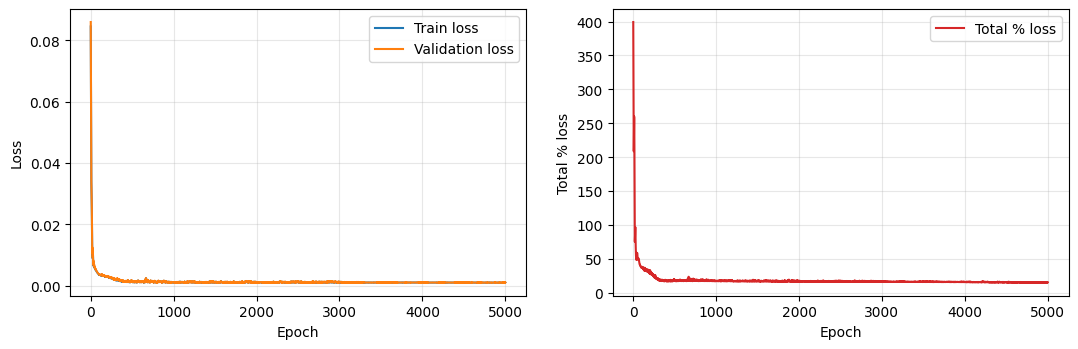

Epoch : 1
Train Loss : 8.444396e-02
Validation Loss : 8.588689e-02
Total % loss : 399.3961          Avg % loss : 79.8792
    P 84.809%  +  E 79.585%  +  S 80.068%  +  nB 83.737%  +  trace 71.197%
save model
Epoch : 2
Train Loss : 7.615277e-02
Validation Loss : 7.763855e-02
Total % loss : 365.6501          Avg % loss : 73.1300
    P 80.609%  +  E 74.272%  +  S 75.390%  +  nB 71.268%  +  trace 64.112%
save model
Epoch : 3
Train Loss : 6.707852e-02
Validation Loss : 6.880316e-02
Total % loss : 322.7199          Avg % loss : 64.5440
    P 74.975%  +  E 67.372%  +  S 69.443%  +  nB 53.840%  +  trace 57.090%
save model
Epoch : 4
Train Loss : 5.807658e-02
Validation Loss : 5.951904e-02
Total % loss : 276.1266          Avg % loss : 55.2253
    P 67.546%  +  E 58.692%  +  S 62.055%  +  nB 36.535%  +  trace 51.299%
save model
Epoch : 5
Train Loss : 4.956133e-02
Validation Loss : 5.068778e-02
Total % loss : 239.7018          Avg % loss : 47.9404
    P 58.243%  +  E 49.366%  +  S 53.402%  +  nB 32

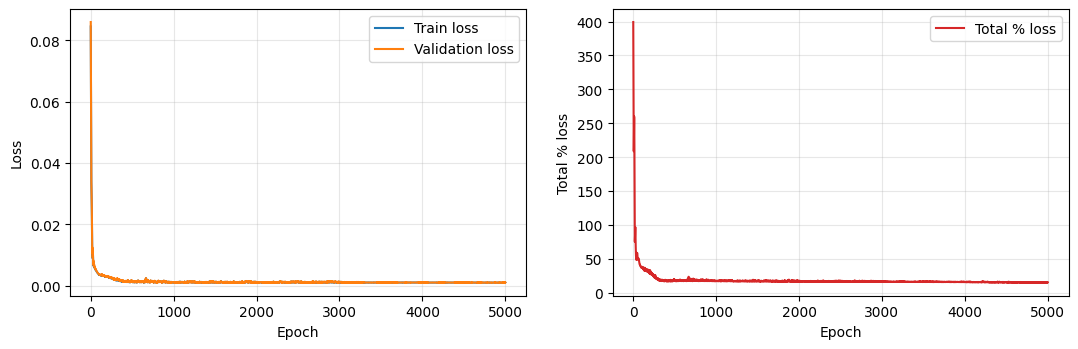

In [8]:
# Block 9
# One Function call to start them all and in the model training bind them
# Press the square Stop button on this cell to halt. Best weights already saved are kept.
Mass_Tmu_train(learning_rate, epochs, path_model, device)